# Predicting Insurance Claims
---

# 1. Model training 
### a.  Missing data checking and handling

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('insurance_data.csv')
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [2]:
df.describe()

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000
mean,6.111688,1.388473,44.823935,18826.858667,3.137066,1162.355851,3.626963,4.852893,3850.476891,1672.233667,1385.276813,1.759950,0.063968
std,4.142790,1.134413,6.935604,17660.174792,1.832641,266.304786,0.483616,0.228061,311.457119,112.089135,212.423085,1.389576,0.244698
min,0.000000,0.000000,35.000000,290.000000,1.000000,796.000000,3.000000,4.500000,3445.000000,1475.000000,1051.000000,0.000000,0.000000
25%,2.100000,0.400000,39.000000,6112.000000,2.000000,796.000000,3.000000,4.600000,3445.000000,1515.000000,1185.000000,0.000000,0.000000
50%,5.700000,1.200000,44.000000,8794.000000,2.000000,1197.000000,4.000000,4.800000,3845.000000,1735.000000,1335.000000,2.000000,0.000000
75%,10.400000,2.200000,49.000000,27003.000000,6.000000,1493.000000,4.000000,5.000000,3995.000000,1755.000000,1510.000000,3.000000,0.000000
max,14.000000,20.000000,75.000000,73430.000000,6.000000,1498.000000,4.000000,5.200000,4300.000000,1811.000000,1720.000000,5.000000,1.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

##### This shows that there is no missing data.
---

### b. Duplicate data checking and handling.
i.  Dropping duplicate rows

ii.  Unique value checking and replacing any possible entity

In [4]:
df.duplicated().any()


np.False_

There is no duplicate data.

In [5]:
#df.drop_duplicates()

In [6]:
df.nunique()

policy_id                           58592
subscription_length                   140
vehicle_age                            49
customer_age                           41
region_code                            22
region_density                         22
segment                                 6
model                                  11
fuel_type                               3
max_torque                              9
max_power                               9
engine_type                            11
airbags                                 3
is_esc                                  2
is_adjustable_steering                  2
is_tpms                                 2
is_parking_sensors                      2
is_parking_camera                       2
rear_brakes_type                        2
displacement                            9
cylinder                                2
transmission_type                       2
steering_type                           3
turning_radius                    

### c.  Encoding approach

In [7]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age',
       'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'steering_type', 'turning_radius', 'length',
       'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status'],
      dtype='object')

In [8]:
df = df.drop('policy_id',axis = 1)

In [9]:
#numeric_features = ['subscription_length', 'vehicle_age', 'customer_age', 'model', 'displacement']
cat_features = ['fuel_type','engine_type', 'region_code','airbags', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'model',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror','is_ecw', 'is_speed_alert']

In [10]:
le = LabelEncoder()
#df_encoded=pd.get_dummies(df, cat_= cat_features, drop_first =True)
for feature in cat_features:
    df[feature] = le.fit_transform(df[feature])

df

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,9.3,1.2,41,20,8794,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
1,8.2,1.8,35,11,27003,C1,10,1,200Nm@1750rpm,97.89bhp@3600rpm,...,0,1,1,1,1,1,1,1,4,0
2,9.5,0.2,44,20,8794,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
3,5.2,0.4,44,1,73430,A,0,0,60Nm@3500rpm,40.36bhp@6000rpm,...,0,0,0,1,0,0,0,1,0,0
4,10.1,1.0,56,4,5410,B2,6,1,200Nm@3000rpm,88.77bhp@4000rpm,...,0,1,1,1,0,0,1,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,17,34738,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58588,2.3,2.2,37,15,4076,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
58589,6.6,2.2,35,20,8794,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58590,4.1,3.6,44,20,8794,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0


In [11]:
numeric_features = ['subscription_length', 'vehicle_age', 'customer_age', 'displacement', 'gross_weight','region_density']

In [12]:
'''df=pd.get_dummies(df, drop_first = 'true')
df'''

"df=pd.get_dummies(df, drop_first = 'true')\ndf"

### Checking Outliers

In [13]:
for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print("Number of outliers:", feature, len(outliers))
    df = df[(df[feature]>= lower_bound) & (df[feature]<= upper_bound)]

print("after removal, number of datas =",len(df))
    
df.shape

Number of outliers: subscription_length 0
Number of outliers: vehicle_age 269
Number of outliers: customer_age 279
Number of outliers: displacement 0
Number of outliers: gross_weight 0
Number of outliers: region_density 3621
after removal, number of datas = 54423


(54423, 40)

##### Data containing outliers are comparatively lesser(<5000) than the total number of  data(>58000). Hence, the samples were dropped to remove the outlier.

fuel_type
2    19236
0    18496
1    16691
Name: count, dtype: int64


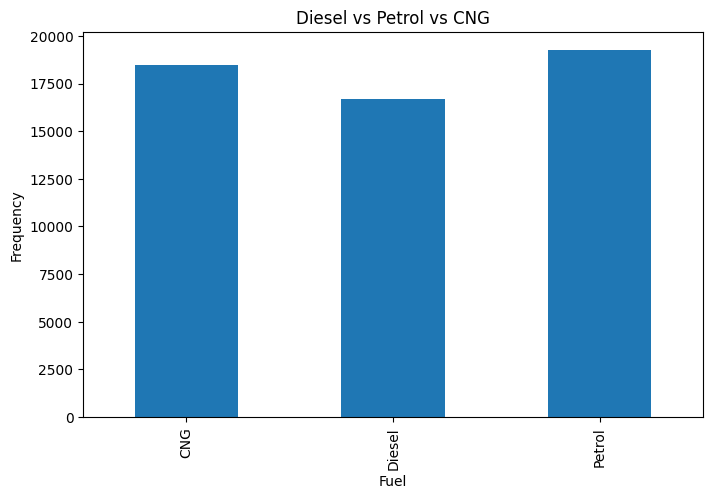

In [14]:
print(df['fuel_type'].value_counts())
plt.figure(figsize=(8, 5))
df['fuel_type'].value_counts().sort_index().plot(kind='bar')
plt.title('Diesel vs Petrol vs CNG')
plt.xticks([0, 1, 2], ['CNG', 'Diesel', 'Petrol'])
plt.xlabel('Fuel')
plt.ylabel('Frequency')
plt.show()


[9.3, 8.2, 9.5, 10.1, 3.1, 4.5, 10.7, 10.7, 0.3, 10.5, 5.3, 10.2, 1.4, 5.6, 10.3, 8.8, 2.4, 9.7, 11.6, 5.3, 10.2, 0.9, 1.2, 1.3, 12.4, 6.8, 0.7, 12.4, 7.7, 8.3, 0.8, 10.6, 2.8, 0.2, 11.8, 6.4, 4.3, 12.1, 5.5, 2.6, 0.9, 10.1, 1.8, 4.6, 2.7, 10.9, 0.9, 2.2, 0.4, 11.7, 10.6, 12.2, 0.8, 3.8, 0.5, 5.0, 1.3, 0.6, 1.0, 0.2, 1.1, 4.9, 1.5, 2.8, 11.2, 12.4, 1.0, 8.2, 4.3, 1.8, 11.1, 5.0, 12.2, 10.6, 0.2, 1.1, 11.1, 10.7, 6.8, 1.1, 11.8, 8.5, 0.1, 5.3, 0.4, 3.1, 7.4, 4.4, 7.7, 2.1, 3.8, 2.2, 7.6, 11.7, 0.9, 5.1, 1.0, 5.7, 0.9, 8.8, 3.4, 0.2, 0.4, 5.6, 2.7, 3.8, 3.2, 11.1, 2.2, 1.4, 8.1, 1.1, 3.0, 8.7, 6.5, 2.8, 2.2, 12.2, 10.4, 10.3, 9.2, 10.5, 9.6, 0.1, 6.8, 2.8, 10.8, 5.7, 10.8, 6.4, 11.6, 3.8, 10.4, 3.8, 3.5, 11.8, 10.3, 11.9, 6.4, 0.0, 8.6, 0.4, 2.4, 10.9, 5.4, 9.0, 10.1, 8.7, 6.6, 10.3, 8.6, 0.9, 12.3, 1.3, 6.3, 2.4, 10.2, 6.6, 5.8, 11.2, 0.1, 7.1, 0.3, 2.9, 0.4, 11.3, 11.1, 3.6, 0.4, 0.8, 10.8, 4.3, 11.3, 10.0, 0.9, 10.1, 1.7, 12.3, 7.3, 2.2, 8.9, 2.6, 10.1, 11.4, 3.0, 0.8, 2.5, 8.7, 1.6, 

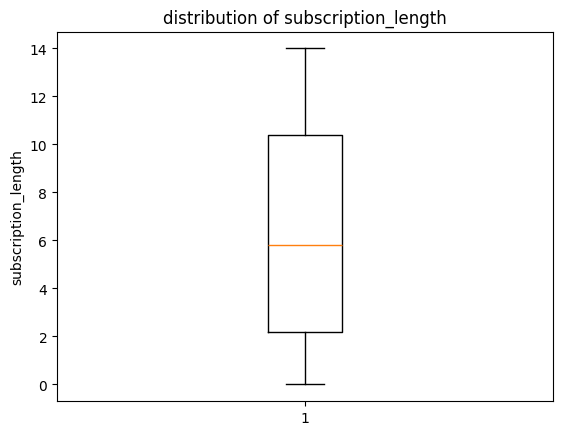

[1.2, 1.8, 0.2, 1.0, 2.0, 2.4, 2.0, 0.6, 2.4, 3.0, 1.2, 1.6, 0.0, 0.2, 3.8, 0.4, 2.8, 1.0, 0.4, 0.8, 1.0, 1.4, 0.2, 0.0, 2.0, 1.4, 0.0, 0.6, 0.0, 1.2, 0.6, 0.8, 1.2, 1.4, 2.0, 2.2, 2.0, 3.8, 0.6, 0.4, 2.2, 2.8, 1.0, 1.2, 0.0, 2.0, 0.4, 3.2, 0.4, 1.2, 3.6, 3.2, 1.4, 2.0, 2.0, 1.4, 3.2, 0.0, 0.4, 0.2, 0.4, 1.4, 1.0, 0.2, 0.4, 2.0, 1.2, 0.2, 2.0, 1.6, 1.4, 1.4, 0.4, 1.6, 1.0, 1.0, 1.0, 2.2, 0.6, 0.0, 1.6, 0.2, 0.0, 0.4, 2.6, 2.6, 0.2, 0.4, 0.8, 0.4, 0.6, 2.4, 1.2, 1.4, 3.0, 0.2, 1.6, 0.0, 3.6, 2.6, 0.2, 2.8, 0.4, 0.6, 0.2, 1.8, 0.8, 2.8, 2.4, 0.8, 1.8, 1.0, 2.4, 0.8, 0.4, 2.4, 0.2, 3.0, 0.4, 0.2, 2.2, 1.0, 0.4, 0.8, 0.2, 1.4, 0.6, 1.0, 1.4, 1.4, 0.4, 0.6, 0.2, 2.0, 3.2, 1.0, 2.4, 1.6, 0.4, 0.8, 0.2, 0.2, 0.6, 1.8, 0.2, 0.8, 2.8, 0.0, 0.2, 1.2, 0.8, 2.2, 1.8, 0.4, 1.0, 1.2, 0.0, 2.4, 1.8, 0.4, 1.0, 1.6, 1.4, 2.0, 0.0, 2.2, 2.0, 0.4, 0.2, 2.4, 1.6, 0.2, 0.6, 2.4, 0.8, 0.2, 0.6, 3.6, 2.6, 3.2, 1.0, 1.6, 2.4, 1.8, 0.8, 1.6, 2.0, 0.6, 0.6, 0.8, 0.2, 3.2, 2.6, 1.6, 2.0, 2.4, 2.8, 0.8, 0.0, 2.4,

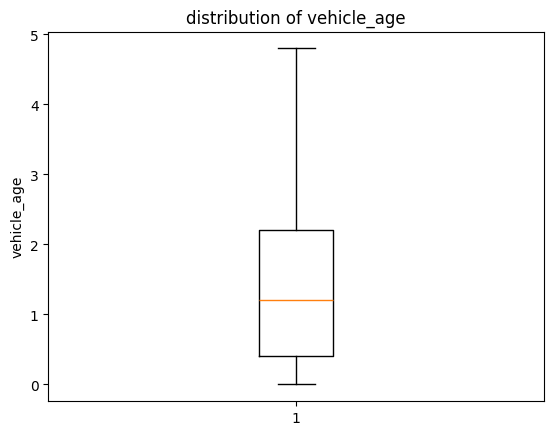

[41, 35, 44, 56, 36, 38, 56, 55, 45, 37, 39, 41, 44, 36, 40, 40, 42, 43, 48, 45, 41, 36, 53, 46, 44, 51, 37, 44, 45, 43, 41, 38, 36, 40, 37, 44, 35, 38, 61, 39, 44, 50, 35, 35, 49, 35, 36, 47, 53, 39, 47, 52, 52, 42, 48, 44, 47, 49, 43, 46, 40, 52, 44, 37, 57, 36, 37, 45, 36, 52, 37, 52, 41, 43, 40, 40, 57, 40, 49, 53, 53, 58, 53, 53, 40, 45, 40, 43, 40, 39, 45, 41, 57, 55, 35, 40, 43, 40, 44, 60, 57, 35, 47, 45, 45, 41, 38, 36, 40, 51, 40, 39, 48, 56, 36, 44, 41, 57, 45, 39, 45, 36, 44, 41, 44, 36, 51, 42, 38, 35, 53, 47, 36, 44, 43, 40, 40, 48, 38, 47, 43, 39, 57, 48, 42, 53, 43, 51, 41, 51, 45, 48, 45, 35, 40, 43, 37, 35, 37, 54, 39, 50, 48, 41, 38, 39, 54, 42, 46, 35, 45, 50, 60, 49, 35, 44, 50, 52, 45, 48, 44, 40, 51, 43, 43, 38, 46, 47, 39, 52, 47, 44, 36, 54, 43, 51, 60, 39, 39, 41, 45, 47, 45, 54, 59, 44, 40, 42, 47, 45, 41, 43, 35, 45, 37, 46, 43, 48, 41, 42, 37, 49, 36, 50, 48, 49, 49, 40, 52, 44, 39, 40, 40, 35, 40, 37, 38, 51, 47, 63, 44, 45, 37, 35, 48, 54, 40, 39, 44, 44,

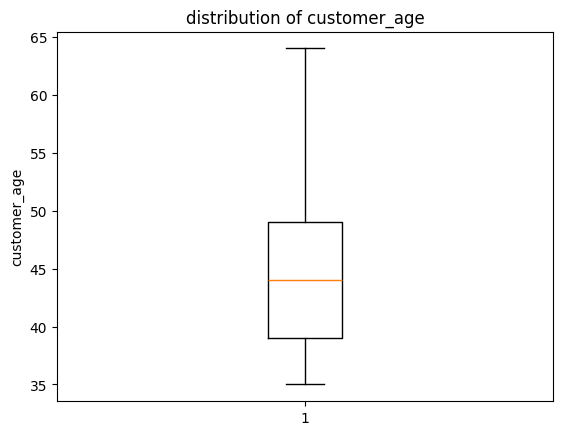

[1493, 1498, 1493, 1497, 1197, 1493, 1197, 998, 1197, 1197, 796, 1493, 796, 796, 1197, 796, 1197, 999, 1197, 1197, 1493, 1493, 796, 796, 1498, 998, 796, 1197, 796, 1197, 998, 796, 1197, 1197, 1493, 999, 1197, 1197, 796, 796, 1493, 1197, 1493, 796, 1196, 999, 1197, 1197, 796, 1197, 1197, 1197, 1493, 1197, 1493, 1197, 1493, 796, 1197, 796, 1498, 1197, 1197, 796, 796, 1197, 1197, 1197, 796, 1196, 1493, 1197, 1498, 1197, 796, 1493, 998, 1493, 1493, 796, 1493, 796, 796, 796, 1197, 1197, 796, 796, 1497, 998, 1493, 1196, 796, 1493, 1493, 796, 1196, 796, 1493, 1197, 1197, 998, 796, 1493, 796, 998, 796, 1493, 1197, 796, 1493, 1498, 1197, 1493, 796, 998, 796, 1493, 1197, 1197, 1197, 999, 796, 1199, 1497, 1493, 796, 1199, 1197, 1197, 1498, 796, 1497, 1197, 999, 1197, 1493, 999, 796, 1493, 796, 796, 796, 998, 796, 1197, 1493, 796, 1197, 1197, 796, 1197, 1493, 796, 1197, 1493, 1493, 1493, 998, 796, 1197, 1498, 1197, 1493, 796, 1197, 1197, 796, 1197, 1493, 1197, 796, 1197, 1197, 1197, 1493, 1196, 14

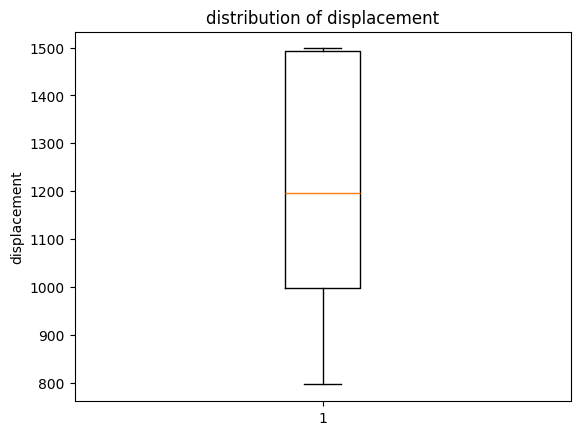

[1720, 1051, 1720, 1490, 1410, 1720, 1335, 1340, 1335, 1335, 1185, 1720, 1185, 1185, 1335, 1185, 1335, 1155, 1410, 1335, 1720, 1720, 1185, 1185, 1051, 1340, 1185, 1335, 1185, 1410, 1340, 1185, 1335, 1335, 1720, 1155, 1335, 1410, 1185, 1185, 1720, 1335, 1720, 1185, 1510, 1155, 1335, 1335, 1185, 1335, 1335, 1335, 1720, 1410, 1720, 1335, 1720, 1185, 1335, 1185, 1051, 1335, 1335, 1185, 1185, 1335, 1335, 1335, 1185, 1510, 1720, 1410, 1051, 1410, 1185, 1720, 1340, 1720, 1720, 1185, 1720, 1185, 1185, 1185, 1335, 1335, 1185, 1185, 1490, 1340, 1720, 1510, 1185, 1720, 1720, 1185, 1510, 1185, 1720, 1335, 1335, 1340, 1185, 1720, 1185, 1340, 1185, 1720, 1335, 1185, 1720, 1051, 1335, 1720, 1185, 1340, 1185, 1720, 1335, 1335, 1335, 1155, 1185, 1660, 1490, 1720, 1185, 1660, 1335, 1410, 1051, 1185, 1490, 1335, 1155, 1335, 1720, 1155, 1185, 1720, 1185, 1185, 1185, 1340, 1185, 1335, 1720, 1185, 1335, 1335, 1185, 1335, 1720, 1185, 1335, 1720, 1720, 1720, 1340, 1185, 1335, 1051, 1335, 1720, 1185, 1335, 133

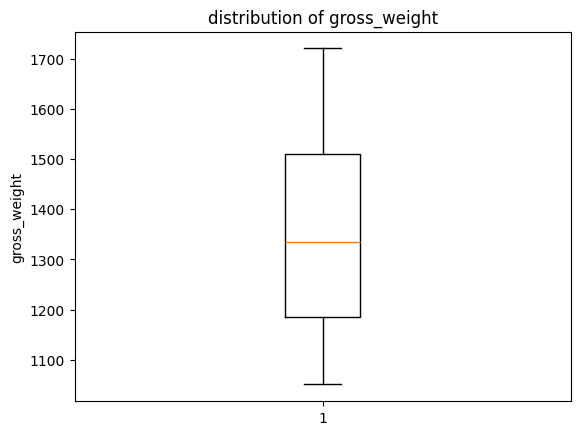

[8794, 27003, 8794, 5410, 6112, 27003, 27003, 34738, 4076, 27742, 8794, 27003, 27003, 4076, 8794, 17804, 27003, 290, 5410, 34738, 27003, 27003, 13051, 4076, 4076, 27003, 4076, 8794, 4076, 27003, 4076, 27003, 8794, 5410, 8794, 27003, 5410, 5410, 4076, 34738, 17804, 27003, 8794, 27742, 4076, 17804, 27003, 8794, 34738, 290, 4076, 5410, 8794, 6108, 8794, 13051, 27742, 5410, 5410, 4990, 34738, 34738, 27003, 6112, 17804, 7788, 6108, 27003, 290, 27003, 4076, 8794, 27003, 27003, 4076, 8794, 34738, 8794, 5410, 4076, 8794, 4076, 4076, 34738, 7788, 4076, 27003, 34738, 7788, 290, 27003, 8794, 34738, 8794, 6112, 34738, 27003, 34791, 21622, 7788, 4076, 27003, 34738, 8794, 13051, 4076, 4076, 3264, 34738, 4076, 8794, 34738, 8794, 27742, 4990, 17804, 27003, 13051, 8794, 27003, 13051, 5410, 4076, 16206, 8794, 8794, 8794, 5410, 4076, 8794, 6108, 17804, 8794, 27003, 4076, 4076, 7788, 8794, 4076, 5410, 34738, 4076, 34738, 34738, 4990, 34738, 7788, 34738, 8794, 6108, 34738, 5410, 8794, 34791, 4990, 34738, 2

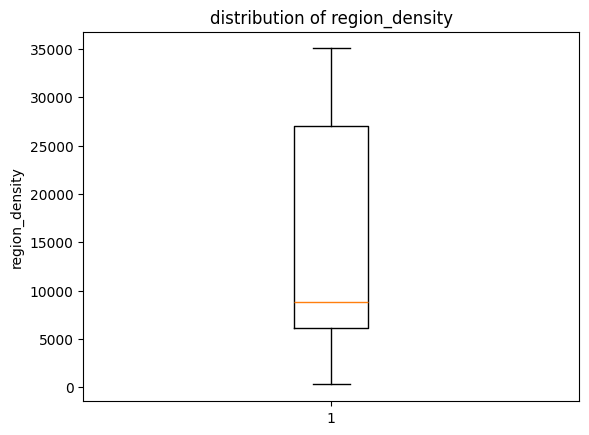

In [15]:
for feature in numeric_features:
    print(value := df[feature].tolist())
    plt.boxplot(value)
    plt.title(f'distribution of {feature}')
    plt.ylabel(feature)
    plt.show()

### No outliers remaining.

In [16]:
for feature in numeric_features:
    min_ = df[feature].min()
    max_ = df[feature].max()
    df[feature] = (df[feature] - min_) / (max_ - min_)
df

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,0.664286,0.250000,0.206897,20,0.244748,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
1,0.585714,0.375000,0.000000,11,0.768808,C1,10,1,200Nm@1750rpm,97.89bhp@3600rpm,...,0,1,1,1,1,1,1,1,4,0
2,0.678571,0.041667,0.310345,20,0.244748,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
4,0.721429,0.208333,0.724138,4,0.147355,B2,6,1,200Nm@3000rpm,88.77bhp@4000rpm,...,0,1,1,1,0,0,1,1,5,0
5,0.221429,0.416667,0.034483,19,0.167559,B2,8,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,0.757143,0.541667,0.448276,17,0.991423,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58588,0.164286,0.458333,0.068966,15,0.108962,C2,5,1,250Nm@2750rpm,113.45bhp@4000rpm,...,1,1,1,1,1,0,1,1,3,0
58589,0.471429,0.458333,0.000000,20,0.244748,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0
58590,0.292857,0.750000,0.310345,20,0.244748,B2,7,2,113Nm@4400rpm,88.50bhp@6000rpm,...,1,1,1,1,1,1,1,1,2,0


In [17]:
print(df['ncap_rating'].value_counts())

ncap_rating
2    20070
0    17330
3    13217
4     1991
5     1815
Name: count, dtype: int64


### e. Assigned EDA
#### 1. Target Variable Analysis (claim_status) 

In [18]:
print(df['claim_status'].value_counts())

claim_status
0    50886
1     3537
Name: count, dtype: int64


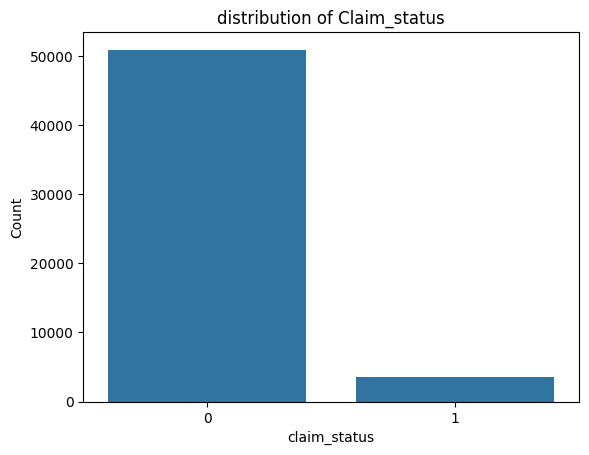

In [19]:
plt.figure('figsize(5,5)')
sns.countplot(x = "claim_status", data = df)
plt.title(f'distribution of Claim_status')
plt.ylabel('Count')
plt.show()



##### Count plot of Claim_status shows heavy imbalance in distribution.
##### Resampling Plan: Apply SMOTE (Synthetic Minority Oversampling Technique) to balance the classes.

=== Claim Status Distribution ===
Not Claimed (0): 50886  (93.50%)
Claimed     (1): 3537  (6.50%)

Imbalance Ratio (majority:minority): 14.39 : 1


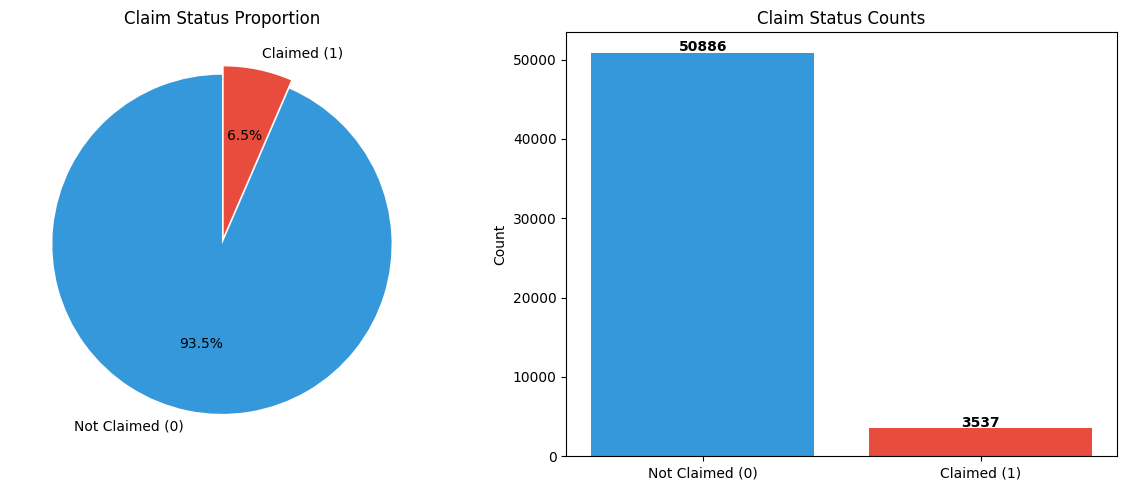

In [20]:
# Detailed class distribution analysis
counts = df['claim_status'].value_counts()
percentages = df['claim_status'].value_counts(normalize=True) * 100
imbalance_ratio = counts[0] / counts[1]

print("=== Claim Status Distribution ===")
print(f"Not Claimed (0): {counts[0]}  ({percentages[0]:.2f}%)")
print(f"Claimed     (1): {counts[1]}  ({percentages[1]:.2f}%)")
print(f"\nImbalance Ratio (majority:minority): {imbalance_ratio:.2f} : 1")

# Pie chart for visual proportion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(counts, labels=['Not Claimed (0)', 'Claimed (1)'], autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, explode=(0, 0.05))
axes[0].set_title('Claim Status Proportion')

# Bar chart with counts annotated
bars = axes[1].bar(['Not Claimed (0)', 'Claimed (1)'], counts, color=['#3498db', '#e74c3c'])
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 str(count), ha='center', fontweight='bold')
axes[1].set_title('Claim Status Counts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Encoding remaining string columns: ['segment', 'max_torque', 'max_power', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type']

=== Before SMOTE ===
claim_status
0    50886
1     3537
Name: count, dtype: int64

=== After SMOTE ===
claim_status
0    50886
1    50886
Name: count, dtype: int64


C:\Users\Acer\AppData\Local\Temp\ipykernel_42568\954185690.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette=['#3498db', '#e74c3c'])
C:\Users\Acer\AppData\Local\Temp\ipykernel_42568\954185690.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, ax=axes[1], palette=['#3498db', '#e74c3c'])


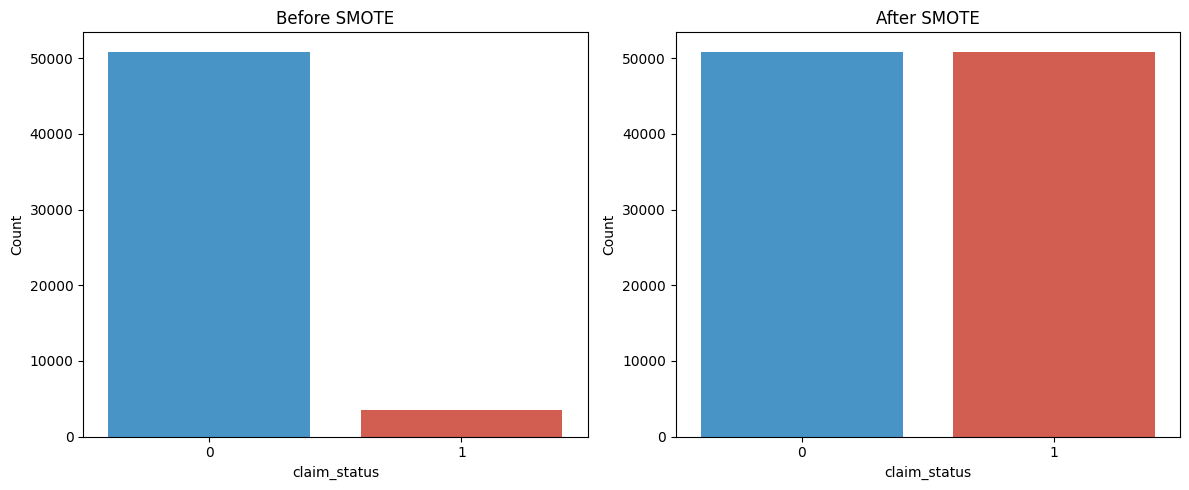


Dataset size: 54423 = 101772 samples


In [21]:
# Apply SMOTE to balance the classes
from imblearn.over_sampling import SMOTE

# Encode remaining non-numeric columns for SMOTE
df_smote = df.copy()
remaining_obj_cols = df_smote.select_dtypes(include='object').columns.tolist()
if remaining_obj_cols:
    print(f"Encoding remaining string columns: {remaining_obj_cols}")
    for col in remaining_obj_cols:
        df_smote[col] = LabelEncoder().fit_transform(df_smote[col])

X = df_smote.drop('claim_status', axis=1)
y = df_smote['claim_status']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Verify distribution after SMOTE
print("\n=== Before SMOTE ===")
print(y.value_counts())
print(f"\n=== After SMOTE ===")
print(y_resampled.value_counts())

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y, ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('claim_status')
axes[0].set_ylabel('Count')

sns.countplot(x=y_resampled, ax=axes[1], palette=['#3498db', '#e74c3c'])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('claim_status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nDataset size: {len(y)} = {len(y_resampled)} samples")

In [22]:
df.shape
print({len(y_resampled)})


{101772}
